In [1]:
import qiskit

In [2]:
qiskit.__version__

'1.3.2'

In [3]:
from qiskit_ibm_runtime import QiskitRuntimeService

In [ ]:
import os
service = QiskitRuntimeService(channel='ibm_quantum', 
                               token = os.environ.get("IBM_QUANTUM_TOKEN", ""))

In [ ]:
# QiskitRuntimeService.save_account(channel='ibm_quantum',
#                                   token= os.environ.get("IBM_QUANTUM_TOKEN", ""))

# 2 qubit bell state - hello world

Map problem to circuits and operators
- Hadamard gate on first qubit (puts into a superposition of 01) then a C-not (results in entire state being 00 + 11)

In [6]:
from qiskit import QuantumCircuit

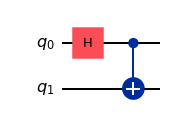

In [7]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)
qc.draw(output='mpl')

In [8]:
from qiskit.quantum_info import Pauli

ZZ = Pauli('ZZ')
ZI = Pauli('ZI')
IZ = Pauli('IZ')
XX = Pauli('XX')
XI = Pauli('XI')
IX = Pauli('IX')
observables = [ZZ,ZI,IZ, XX,XI,IX]

Optimize the circuit observables

Execute on backend

In [9]:
from qiskit_aer.primitives import Estimator

estimator = Estimator()

In [10]:
job = estimator.run([qc] * len(observables), observables)

In [11]:
job.result()

EstimatorResult(values=array([ 1.        , -0.05273438, -0.05273438,  1.        ,  0.01953125,
        0.01953125]), metadata=[{'shots': 1024, 'variance': 0.0, 'simulator_metadata': [{'num_bind_params': 1, 'runtime_parameter_bind': False, 'parallel_state_update': 8, 'parallel_shots': 1, 'sample_measure_time': 0.001021375, 'noise': 'ideal', 'batched_shots_optimization': False, 'remapped_qubits': False, 'active_input_qubits': [0, 1], 'device': 'CPU', 'time_taken': 0.00604625, 'measure_sampling': True, 'num_clbits': 2, 'max_memory_mb': 8192, 'input_qubit_map': [[1, 1], [0, 0]], 'num_qubits': 2, 'method': 'stabilizer', 'required_memory_mb': 0, 'fusion': {'enabled': False}}]}, {'shots': 1024, 'variance': 0.9972190856933594, 'simulator_metadata': [{'num_bind_params': 1, 'runtime_parameter_bind': False, 'parallel_state_update': 8, 'parallel_shots': 1, 'sample_measure_time': 0.001021375, 'noise': 'ideal', 'batched_shots_optimization': False, 'remapped_qubits': False, 'active_input_qubits': [0,

Post processing and plotting

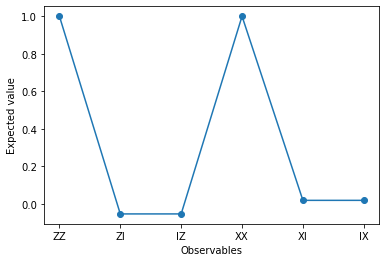

In [12]:
import matplotlib.pyplot as plt

data = ['ZZ','ZI','IZ', 'XX','XI','IX']
values = job.result().values

plt.plot(data, values, '-o')
plt.xlabel('Observables')
plt.ylabel('Expected value')
plt.show()

Extend example to n-qubit GHZ state

Map the problem to circuits and operators



In [17]:
def get_qc_for_n_qubit_GHZ_state(n):
    qc = QuantumCircuit(n)
    qc.h(0)
    for i in range(n-1):
        qc.cx(i, i+1)
    return qc

n = 100
qc = get_qc_for_n_qubit_GHZ_state(n)
qc.draw(output='mpl')

In [18]:
from qiskit.quantum_info import SparsePauliOp

operator_strings = ['Z' + 'I' * i + 'Z' + 'I' * (n-2-i) for i in range(n-1)]
print(operator_strings)
print(len(operator_strings))

operators = [SparsePauliOp(operator_string) for operator_string in operator_strings]

['ZZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'ZIIIIIIIIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII

Optimize for quantum execution

In [19]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

backend_name = 'ibm_brisbane'
backend = QiskitRuntimeService().backend(backend_name)
pass_manager = generate_preset_pass_manager(optimization_level=1, backend=backend)

qc_transpiled = pass_manager.run(qc)
operators_transpiled_list = [op.apply_layout(qc_transpiled.layout) for op in operators]

Execute on backend

In [21]:
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import EstimatorOptions
from qiskit import transpile
from qiskit.quantum_info import SparsePauliOp

# Define Estimator options
options = EstimatorOptions()
options.resilience_level = 1  # Use measurements without mitigation
options.dynamical_decoupling.enable = True
options.dynamical_decoupling.sequence_type = 'XY4'

# Transpile the circuit with optimization level
qc_transpiled = transpile(qc, backend, optimization_level=0)

# Create an Estimator instance with the updated options
estimator = Estimator(backend, options=options)

# Run the job (ensure proper formatting)
job = estimator.run([(qc_transpiled, operators_transpiled_list[0])])  # Using first observable
job_id = job.job_id()
print(job_id)


cytv2gtjj6dg008g3de0


Plotting

In [22]:
job_id = 'cytv2gtjj6dg008g3de0'
service = QiskitRuntimeService()
job = service.job(job_id)

In [25]:
data = list(range(1, len(operators)+1))
result = job.result()[0]
values = result.data.evs
values = (v/values for v in values)


plt.scatter(data, values, marker = 'o', label = '100-qubit GHZ state')
plt.xlabel('Distance between qubits $i$')
plt.ylabel(r'\langle Z_0 Z_i \rangle / \langle Z_0 Z_1 \rangle$')
plt.legend()
plt.show()

TypeError: iteration over a 0-d array